In [1]:
import os
import shutil

# Step 1: Create a folder named "ecg_data" in the current directory
os.makedirs("ecg_data", exist_ok=True)

# Step 2: Move all MIT-BIH files into that folder
for filename in os.listdir("/content"):
    if filename.endswith(('.dat', '.atr', '.hea', '.xws')):
        shutil.move(os.path.join("/content", filename), "ecg_data")



In [2]:
# Check if files are inside ecg_data now
print(os.listdir("ecg_data"))


['233.dat', '212.hea', '103.hea', '105.hea', '217.hea', '230.dat', '113.xws', '115.dat', '214.atr', '116.dat', '106.hea', '111.dat', '117.dat', '207.dat', '123.atr', '122.atr', '108.dat', '122.dat', '119.atr', '208.dat', '214.hea', '107.atr', '109.atr', '213.dat', '209.atr', '208.atr', '124.atr', '203.dat', '233.atr', '112.xws', '212.atr', '111.xws', '100.atr', '205.atr', '215.xws', '200.dat', '113.hea', '116.hea', '210.xws', '104.xws', '203.hea', '228.atr', '108.hea', '116.atr', '219.xws', '231.xws', '124.hea', '234.hea', '207.xws', '215.dat', '231.atr', '201.xws', '111.hea', '220.xws', '234.dat', '220.hea', '114.dat', '219.atr', '123.dat', '232.atr', '223.dat', '104.dat', '200.hea', '112.atr', '201.dat', '230.xws', '213.hea', '106.dat', '201.hea', '214.dat', '121.atr', '202.xws', '219.hea', '121.xws', '105.dat', '203.xws', '212.dat', '101.hea', '207.atr', '205.dat', '234.atr', '118.atr', '231.hea', '109.hea', '223.hea', '222.dat', '123.hea', '223.atr', '119.hea', '220.dat', '217.dat'

In [3]:
!pip install wfdb


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.8/163.8 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.1/13.1 MB 89.0 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.2.3 which is incompatible.


In [4]:
import wfdb

data_dir = "ecg_data"

# Get all record names (excluding the file extension)
record_names = sorted(set(f.split('.')[0] for f in os.listdir(data_dir) if f.endswith('.dat')))

print("Found records:", record_names)

# Example: Read one sample record
record = wfdb.rdrecord(os.path.join(data_dir, record_names[0]))
annotation = wfdb.rdann(os.path.join(data_dir, record_names[0]), 'atr')

print("Sample data shape:", record.p_signal.shape)
print("Annotation symbols:", annotation.symbol[:10])


Found records: ['100', '101', '102', '103', '104', '105', '106', '107', '108', '109', '111', '112', '113', '114', '115', '116', '117', '118', '119', '121', '122', '123', '124', '200', '201', '202', '203', '205', '207', '208', '209', '210', '212', '213', '214', '215', '217', '219', '220', '221', '222', '223', '228', '230', '231', '232', '233', '234']
Sample data shape: (650000, 2)
Annotation symbols: ['+', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'A', 'N']


In [5]:
import os

# Path to your ECG dataset folder
data_dir = '/content/ecg_data'  # Change this to your local path if needed

# Get all `.dat` files and extract the record names (e.g., '232', '233')
record_names = [f.split('.')[0] for f in os.listdir(data_dir) if f.endswith('.dat')]

# Remove duplicates if multiple .dat per record
record_names = list(set(record_names))
print("Records:", record_names)


Records: ['107', '212', '232', '203', '233', '213', '207', '217', '219', '220', '209', '113', '106', '228', '104', '124', '222', '105', '118', '114', '223', '102', '200', '234', '112', '214', '231', '100', '215', '210', '221', '115', '108', '109', '230', '117', '123', '208', '119', '122', '111', '205', '116', '103', '202', '121', '201', '101']


In [6]:
import wfdb
import numpy as np

all_beats = []
all_labels = []

window_size = 100

for record_name in record_names:
    try:
        record = wfdb.rdrecord(f'{data_dir}/{record_name}')
        annotation = wfdb.rdann(f'{data_dir}/{record_name}', 'atr')

        signal = record.p_signal[:, 0]  # First channel
        r_peaks = annotation.sample
        labels = annotation.symbol

        for i in range(len(r_peaks)):
            idx = r_peaks[i]
            if idx - window_size > 0 and idx + window_size < len(signal):
                beat = signal[idx - window_size : idx + window_size]
                all_beats.append(beat)
                all_labels.append(labels[i])

    except Exception as e:
        print(f"Failed to process {record_name}: {e}")


In [7]:
from sklearn.preprocessing import LabelEncoder

# Optional: filter only a subset of labels you're interested in
# For example: only ['N', 'A', 'V', 'L', 'R']
filtered_beats = []
filtered_labels = []

allowed_labels = ['N', 'A', 'V', 'L', 'R']

for beat, label in zip(all_beats, all_labels):
    if label in allowed_labels:
        filtered_beats.append(beat)
        filtered_labels.append(label)

X = np.array(filtered_beats)
y = np.array(filtered_labels)

# Encode labels to integers
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Classes:", label_encoder.classes_)


Classes: ['A' 'L' 'N' 'R' 'V']


In [8]:
from sklearn.model_selection import train_test_split

X = X.reshape(X.shape[0], X.shape[1], 1)  # reshape for CNN
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)


In [9]:
import tensorflow as tf
from tensorflow.keras import layers, models, Input

# Dense Block
def dense_block(x, num_convs, growth_rate):
    for _ in range(num_convs):
        out = layers.BatchNormalization()(x)
        out = layers.ReLU()(out)
        out = layers.Conv1D(growth_rate, kernel_size=3, padding='same')(out)
        x = layers.Concatenate()([x, out])
    return x

# Transition Layer
def transition_layer(x, reduction):
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.Conv1D(int(x.shape[-1] * reduction), kernel_size=1)(x)
    x = layers.AveragePooling1D(pool_size=2, strides=2)(x)
    return x

# Input shape
input_shape = (X.shape[1], 1)
inputs = Input(shape=input_shape)

# Initial Conv Layer
x = layers.Conv1D(16, kernel_size=7, strides=2, padding='same')(inputs)
x = layers.BatchNormalization()(x)
x = layers.ReLU()(x)
x = layers.MaxPooling1D(pool_size=3, strides=2, padding='same')(x)

# Dense Blocks
x = dense_block(x, num_convs=4, growth_rate=12)
x = transition_layer(x, reduction=0.5)
x = dense_block(x, num_convs=4, growth_rate=12)
x = transition_layer(x, reduction=0.5)

# Final classification layers
x = layers.GlobalAveragePooling1D()(x)
x = layers.Dense(64, activation='relu')(x)
outputs = layers.Dense(len(label_encoder.classes_), activation='softmax')(x)

# Build and compile
densenet_model = models.Model(inputs=inputs, outputs=outputs)
densenet_model.compile(optimizer='adam',
                       loss='sparse_categorical_crossentropy',
                       metrics=['accuracy'])

# Train
history = densenet_model.fit(X_train, y_train, epochs=15, batch_size=32,
                             validation_data=(X_test, y_test))


Epoch 1/15
2501/2501 ━━━━━━━━━━━━━━━━━━━━ 92s 31ms/step - accuracy: 0.8999 - loss: 0.3377 - val_accuracy: 0.9650 - val_loss: 0.1344
Epoch 2/15
2501/2501 ━━━━━━━━━━━━━━━━━━━━ 88s 33ms/step - accuracy: 0.9684 - loss: 0.1171 - val_accuracy: 0.9739 - val_loss: 0.0944
Epoch 3/15
2501/2501 ━━━━━━━━━━━━━━━━━━━━ 76s 30ms/step - accuracy: 0.9727 - loss: 0.0944 - val_accuracy: 0.9629 - val_loss: 0.1351
Epoch 4/15
2501/2501 ━━━━━━━━━━━━━━━━━━━━ 82s 31ms/step - accuracy: 0.9788 - loss: 0.0742 - val_accuracy: 0.9761 - val_loss: 0.1001
Epoch 5/15
2501/2501 ━━━━━━━━━━━━━━━━━━━━ 82s 31ms/step - accuracy: 0.9812 - loss: 0.0661 - val_accuracy: 0.9303 - val_loss: 0.2272
Epoch 6/15
2501/2501 ━━━━━━━━━━━━━━━━━━━━ 75s 30ms/step - accuracy: 0.9837 - loss: 0.0542 - val_accuracy: 0.9832 - val_loss: 0.0613
Epoch 7/15
2501/2501 ━━━━━━━━━━━━━━━━━━━━ 83s 31ms/step - accuracy: 0.9867 - loss: 0.0470 - val_accuracy: 0.9866 - val_loss: 0.0508
Epoch 8/15
2501/2501 ━━━━━━━━━━━━━━━━━━━━ 76s 30ms/step - accuracy: 0.9877 -

In [10]:
from sklearn.ensemble import RandomForestClassifier

X_rf = X.reshape(X.shape[0], -1)
X_rf_train, X_rf_test, y_rf_train, y_rf_test = train_test_split(X_rf, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_rf_train, y_rf_train)

rf_accuracy = rf_model.score(X_rf_test, y_rf_test)
print("Random Forest Accuracy:", rf_accuracy)


Random Forest Accuracy: 0.9842555105713


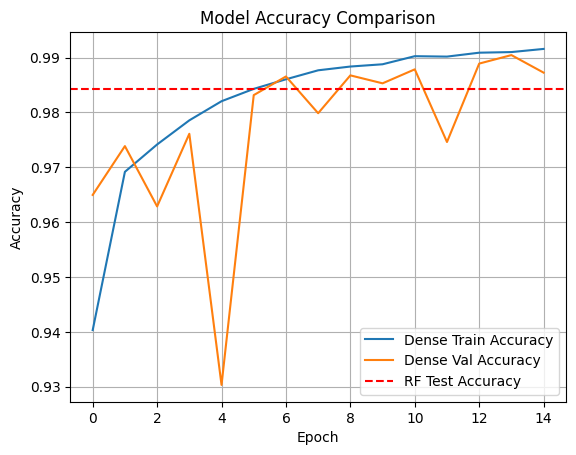

In [12]:
import matplotlib.pyplot as plt

# CNN Accuracy
plt.plot(history.history['accuracy'], label='Dense Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Dense Val Accuracy')
plt.axhline(rf_accuracy, color='red', linestyle='--', label='RF Test Accuracy')
plt.title("Model Accuracy Comparison")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()


In [17]:
!pip install scikit-learn


626/626 ━━━━━━━━━━━━━━━━━━━━ 12s 18ms/step


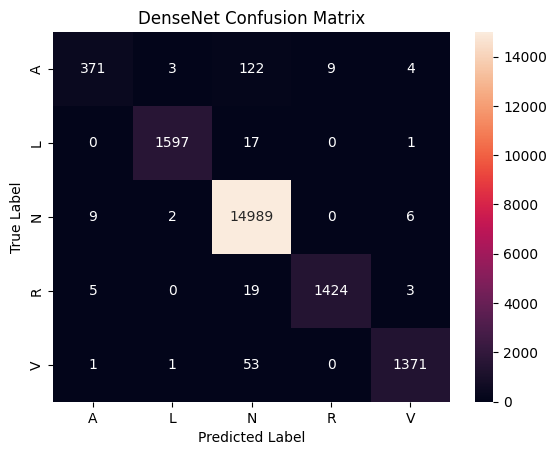

DenseNet Classification Report:
              precision    recall  f1-score   support

           A       0.96      0.73      0.83       509
           L       1.00      0.99      0.99      1615
           N       0.99      1.00      0.99     15006
           R       0.99      0.98      0.99      1451
           V       0.99      0.96      0.98      1426

    accuracy                           0.99     20007
   macro avg       0.99      0.93      0.96     20007
weighted avg       0.99      0.99      0.99     20007



In [19]:
from sklearn.metrics import confusion_matrix, classification_report

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Predict using DenseNet model
y_pred_dense = densenet_model.predict(X_test)
y_pred_labels_dense = np.argmax(y_pred_dense, axis=1)

# Confusion Matrix
cm_dense = confusion_matrix(y_test, y_pred_labels_dense)

# Plot confusion matrix
sns.heatmap(cm_dense, annot=True, fmt='d', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title("DenseNet Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# Classification Report
print("DenseNet Classification Report:")
print(classification_report(y_test, y_pred_labels_dense, target_names=label_encoder.classes_))



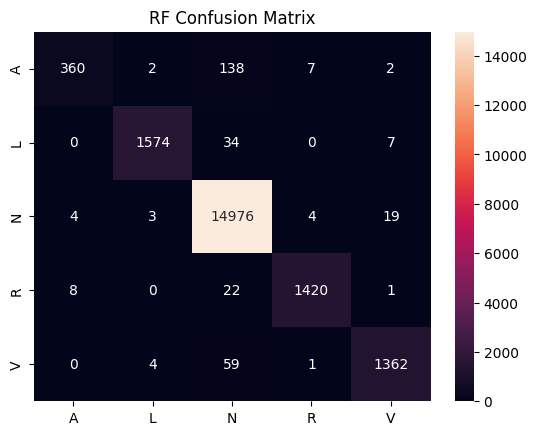

In [20]:
y_rf_pred = rf_model.predict(X_rf_test)

cm_rf = confusion_matrix(y_rf_test, y_rf_pred)
sns.heatmap(cm_rf, annot=True, fmt='d', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title("RF Confusion Matrix")
plt.show()


In [21]:
import numpy as np

# Predict probabilities on test set using DenseNet
DENSE_preds = densenet_model.predict(X_test)

# Get the predicted class (highest probability)
dense_pred_labels = np.argmax(DENSE_preds, axis=1)

# Compare with actual labels
for i in range(10):  # Show 10 random samples
    print(f"Actual: {label_encoder.inverse_transform([y_test[i]])[0]} | Predicted: {label_encoder.inverse_transform([dense_pred_labels[i]])[0]}")


626/626 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step
Actual: N | Predicted: N
Actual: R | Predicted: R
Actual: N | Predicted: N
Actual: N | Predicted: N
Actual: A | Predicted: A
Actual: N | Predicted: N
Actual: V | Predicted: V
Actual: L | Predicted: L
Actual: V | Predicted: V
Actual: R | Predicted: N


In [22]:
rf_preds = rf_model.predict(X_rf_test)

for i in range(10):
    print(f"Actual: {label_encoder.inverse_transform([y_rf_test[i]])[0]} | Predicted: {label_encoder.inverse_transform([rf_preds[i]])[0]}")


Actual: N | Predicted: N
Actual: R | Predicted: R
Actual: N | Predicted: N
Actual: N | Predicted: N
Actual: A | Predicted: A
Actual: N | Predicted: N
Actual: V | Predicted: V
Actual: L | Predicted: L
Actual: V | Predicted: V
Actual: R | Predicted: R


In [24]:
# Select one beat from the test set
# Correct reshape (matches original training shape)
new_beat = X_test[1]
new_beat_Dense = new_beat.reshape(1, 200, 1)
dense_new_pred = densenet_model.predict(new_beat_Dense)
predicted_class = np.argmax(dense_new_pred)
print("Predicted Class:", label_encoder.inverse_transform([predicted_class])[0])




1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
Predicted Class: R


In [25]:
new_beat_rf = X_rf_test[1].reshape(1, -1)
rf_new_pred = rf_model.predict(new_beat_rf)
print("Predicted Class:", label_encoder.inverse_transform(rf_new_pred)[0])


Predicted Class: R
